# Exercise · Playing with Node Embeddings

**Session 08 — Graphs**

In this lab you will turn a graph into vectors with your own hands, using the
**DeepWalk recipe**, and watch community structure appear in the geometry.

The recipe has four moving parts — you implement the key line of each:

1. **Random walks** — wander the graph to make "sentences" of nodes.
2. **(target, context) pairs** — slide a window over each walk.
3. **Skip-gram training** — learn one vector per node so that nodes appearing
   together in walks get similar vectors.
4. **Look + check** — plot the vectors, and test whether they recovered the
   community split with no labels.

### How to use this notebook
- Run the cells top to bottom.
- Wherever you see **`# TODO`**, replace the `...` with your own code.
- Hints are in the comments. The model cell (Part 4) is given to you — just read
  and run it.
- If a cell errors before you've filled in an earlier TODO, that's expected —
  go back and complete it.

In [1]:
# Run this cell as-is. If it errors, install the requirements (see README.md).
import numpy as np
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

%matplotlib inline
np.random.seed(0)
torch.manual_seed(0)
print("ready")

ready


## Part 1 · The graph

We use **Zachary's Karate Club**: 34 members of a 1970s karate club that later
split into two factions. The faction labels (`y_true`) are the *ground truth* —
we will keep them hidden from the embedding and only use them at the very end to
check our work.

Nodes: 34, Edges: 78



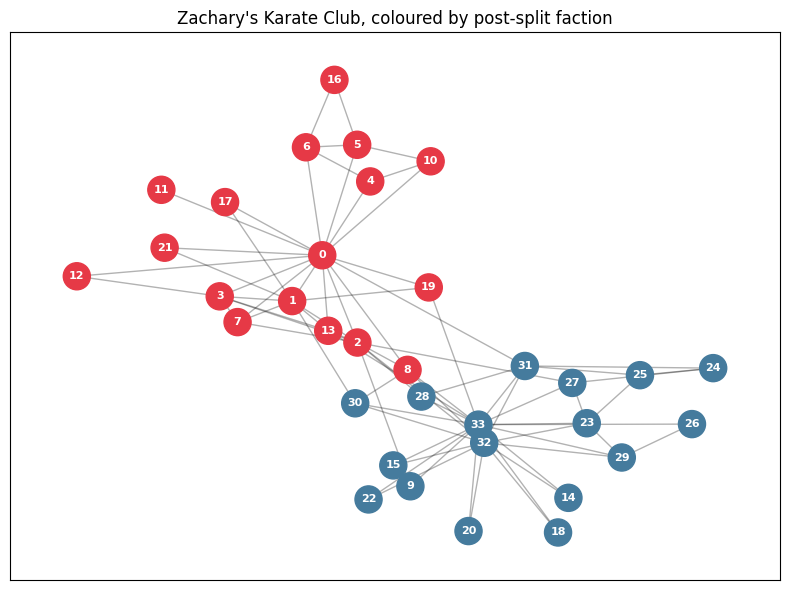

In [2]:
G = nx.karate_club_graph()
N = G.number_of_nodes()
y_true = np.array([0 if G.nodes[i]["club"] == "Mr. Hi" else 1 for i in G.nodes()])
FACTION_COLORS = np.array(["#e63946", "#457b9d"])     # red = Mr. Hi, blue = Officer
pos = nx.spring_layout(G, seed=42)                    # fixed layout, reuse everywhere

# TODO: print the number of nodes and edges, then draw the graph with nx.draw,
#       colouring each node by its faction.
#       hint: node_color = FACTION_COLORS[y_true] ; nx.draw(G, pos, node_color=...,
#             with_labels=True, node_size=300)
E = G.number_of_edges()
print(f"Nodes: {N}, Edges: {E}")
print()
fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=FACTION_COLORS[y_true], node_size=380)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color='white', font_weight='bold')
ax.set_title("Zachary's Karate Club, coloured by post-split faction")
#ax.legend(loc='lower right'); ax.set_axis_off()
plt.tight_layout(); plt.show()

## Part 2 · Random walks

A **random walk** starts at some node and repeatedly steps to a *random
neighbour*. A walk that starts inside a tight community tends to stay there — so
the walks quietly encode community structure.

Each walk is a "sentence"; each node is a "word".

In [3]:
def random_walk(G, start, length, rng):
    """One random walk: from the current node, step to a random neighbour."""
    walk = [start]
    for _ in range(length - 1):
        current = walk[-1]
        neighbors = list(G.neighbors(current))
        if not neighbors:
            break
        # TODO: pick ONE random neighbour and append it to `walk`.
        #       hint: rng.choice(neighbors) returns a random element of the list
        next_node = rng.choice(neighbors)          # <-- replace ... with your code
        walk.append(int(next_node))
    return walk


# quick test (works once your TODO is filled in):
test_rng = np.random.default_rng(0)
print("a length-10 walk from node 0:", random_walk(G, 0, 10, test_rng))

a length-10 walk from node 0: [0, 19, 1, 13, 1, 3, 0, 2, 0, 3]


In [4]:
def generate_walks(G, walks_per_node=10, walk_length=20, seed=0):
    """Run several random walks starting from every node. (provided — just run it)"""
    rng = np.random.default_rng(seed)
    walks = []
    for _ in range(walks_per_node):
        for v in G.nodes():
            walks.append(random_walk(G, v, walk_length, rng))
    return walks


walks = generate_walks(G)
print(f"generated {len(walks)} walks")
print("example walk:", walks[0])

generated 340 walks
example walk: [0, 19, 1, 13, 1, 3, 0, 2, 0, 3, 12, 3, 13, 2, 13, 33, 29, 32, 22, 33]


## Part 3 · From walks to (target, context) pairs

We now turn the walks into training examples. Slide a window of size `window`
along each walk: every node is a **target**, and the nodes within `window` steps
of it are its **context**.

Example with `window = 2` and walk `[7, 3, 9, 1, 5]`:
the target `9` (at index 2) produces the context pairs
`(9, 7)`, `(9, 3)`, `(9, 1)`, `(9, 5)`.

In [5]:
def walks_to_pairs(walks, window=2):
    """Slide a window over each walk to collect (target, context) pairs."""
    pairs = []
    for walk in walks:
        for i, target in enumerate(walk):
            # TODO: for every position j between i-window and i+window (inclusive),
            #       that is still inside the walk and is not i itself,
            #       append the tuple (target, walk[j]) to `pairs`.
            #       hint: lo = max(0, i - window) ; hi = min(len(walk), i + window + 1)
            lo = max(0, i-window)
            hi = min(len(walk), i + window + 1)              # <-- your code here
            for j in range(lo,hi):
                if j != i:
                    pairs.append((target, walk[j]))
    return np.array(pairs, dtype=np.int64)

# print(walks)
pairs = walks_to_pairs(walks)
print(f"collected {len(pairs)} (target, context) pairs")
print("first 5 pairs:", pairs[:5].tolist())

collected 25160 (target, context) pairs
first 5 pairs: [[0, 19], [0, 1], [19, 0], [19, 1], [19, 13]]


## Part 4 · Train the embedding (model provided)

The model below is a single **lookup table** with one vector per node. Training
nudges the vectors so that the dot product of a `(target, context)` pair is
large, while the dot product with a few random "negative" nodes is small —
this is **skip-gram with negative sampling**.

**You do not need to edit the next cell** — read it, then run it.

In [6]:
class NodeEmb(nn.Module):
    """One trainable vector per node; dot product = similarity score."""
    def __init__(self, n_nodes, dim=2):
        super().__init__()
        self.E = nn.Embedding(n_nodes, dim)
        nn.init.normal_(self.E.weight, std=0.1)

    def forward(self, target, context, neg):
        t = self.E(target)                              # (B, dim)
        c = self.E(context)                             # (B, dim)
        ne = self.E(neg)                                # (B, K, dim)
        pos_score = (t * c).sum(-1)                     # target . context
        neg_score = torch.einsum("bd,bkd->bk", t, ne)   # target . negatives
        # want pos_score large and neg_score small:
        return -(F.logsigmoid(pos_score).mean() + F.logsigmoid(-neg_score).mean())

In [7]:
target = torch.tensor(pairs[:, 0])
context = torch.tensor(pairs[:, 1])

torch.manual_seed(0)
model = NodeEmb(N, dim=2)                     # dim=2 so we can plot it directly
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
rng = np.random.default_rng(1)

EPOCHS = 300
for epoch in range(EPOCHS):
    neg = torch.tensor(rng.integers(0, N, size=(len(pairs), 5)))   # 5 negatives / pair
    loss = model(target, context, neg)
    # TODO: the standard PyTorch update — three lines, in this order:
    #       1) clear the old gradients   (optimizer.zero_grad)
    #       2) back-propagate the loss   (loss.backward)
    #       3) take one optimiser step   (optimizer.step)
    ...                                # <-- your three lines here
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f"final loss: {loss.item():.4f}")

final loss: 1.1721


## Part 5 · Look at your embedding

Each node now has a 2-D vector. Because we trained with `dim = 2` we can plot
those vectors directly — no dimensionality reduction needed.

✏️ **Before you plot — predict:** do you expect the two factions to be mixed
together or separated? Write your guess here, then check it below.

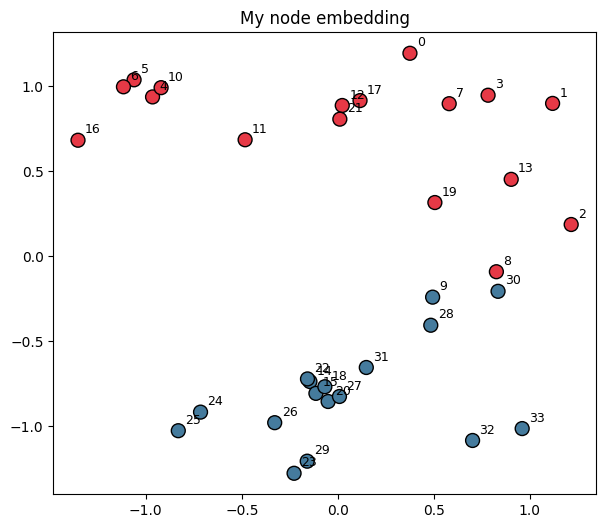

In [8]:
emb = model.E.weight.detach().numpy()        # shape (N, 2): your trained node vectors

fig, ax = plt.subplots(figsize=(7, 6))
# TODO: scatter-plot the embedding.
#       - x coordinates: emb[:, 0]   y coordinates: emb[:, 1]
#       - colour each point by its faction (FACTION_COLORS[y_true])
#       - optional: annotate each point with its node number using ax.annotate
# Disegna i punti (scatter plot)
ax.scatter(emb[:, 0], emb[:, 1], c=FACTION_COLORS[y_true], s=100, edgecolors='black', zorder=2)

# Etichetta ogni punto con il suo ID numerico per capire chi è chi
for i in range(len(emb)):
    ax.annotate(str(i), 
                (emb[i, 0], emb[i, 1]), 
                fontsize=9, 
                xytext=(5, 5),          # Sposta leggermente il testo per non coprire il punto
                textcoords='offset points')
ax.set_title("My node embedding")
plt.show()

## Part 6 · Did it work?

The real test: can the embedding recover the club split **without ever seeing
the labels**? We cluster the vectors into 2 groups with KMeans and compare to
the true factions.

In [9]:
# cluster the embedding into 2 groups -- note: y_true is NOT used here
km = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(emb)

# TODO: compute how often the clustering matches the true factions.
#       The cluster ids (0/1) are arbitrary, so the "right" labelling could be
#       flipped -- try both and keep the better score.
#       hint: (km == y_true).mean()  is one matching; (km != y_true).mean() is the other
accuracy = max((km == y_true).mean(), (km != y_true).mean()) # <-- your code here
print(f"the clustering matches the real split {accuracy:.0%} of the time")

the clustering matches the real split 97% of the time


## Part 7 · Your playground

You have a working pipeline. Now experiment — change **one** thing at a time,
re-run Parts 2–6, and see what happens:

- **walk length** — try very short (`3`) vs. long (`40`). What breaks, what improves?
- **walks per node** — fewer vs. more walks.
- **window size** in `walks_to_pairs`.
- **embedding dim** — try `dim = 8`. (Note: with `dim > 2` you can no longer
  scatter the vectors directly — you would first reduce to 2-D, e.g. with PCA.)

Use the cell below as scratch space, and jot down what you observe.

In [10]:
# --- scratch space: your experiments ---


## Wrap-up — questions to answer

Write a sentence or two for each:

1. Why do nodes from the **same faction** end up close together in the embedding,
   even though we never told the model which faction anyone is in?
2. What happens to the embedding if you make the walks **very short**? Why?
3. The model only ever sees integer node ids and `(target, context)` pairs — it
   has no idea what a "graph" is. Where, exactly, did the graph structure enter?

*Companion to demo `d1` (the same recipe, fully worked) and `d3` (node2vec, link
prediction, and GNNs).*